# Qestion 1
Part A

In [1]:
import numpy as np
import pandas as pd

# probability density function
m0 = np.array([-1, -1, -1, -1])
C0 = np.array([[2, -0.5, 0.3, 0],
               [-0.5, 1, -0.5, 0],
               [0.3, -0.5, 1, 0],
               [0, 0, 0, 2]])

m1 = np.array([1, 1, 1, 1])
C1 = np.array([[1, 0.3, -0.2, 0],
               [0.3, 2, 0.3, 0],
               [-0.2, 0.3, 1, 0],
               [0, 0, 0, 3]])

p_L0 = 0.35
p_L1 = 0.65

In [115]:
# Uncomment it ONLY if you need to generate new set of samples
"""
# generate random labels
labels = np.random.choice([0, 1], 10000, p = [p_L0, p_L1])
print(labels)

# generate random samples with the given label and save it in a dataframe
samples = pd.DataFrame(columns = ['labels', 'X1', 'X2', 'X3', 'X4'])
samples['labels'] = labels

for i in range(10000):
    if labels[i] == 0:
        samples.iloc[i, 1:] = np.random.multivariate_normal(m0, C0)
    else:
        samples.iloc[i, 1:] = np.random.multivariate_normal(m1, C1)

# save the samples with labels as csv
samples.to_csv('samples.csv', index=False)
samples
"""
samples = pd.read_csv('samples.csv')
samples.head()

,labels,X1,X2,X3,X4
0,1,0.058897,0.426004,2.497718,3.326163
1,1,0.859798,-2.068127,0.464932,0.216896
2,1,-0.281237,0.278568,1.023847,-3.072739
3,0,0.150253,-0.717872,-0.788928,-3.106349
4,0,0.346241,-1.051211,-1.020456,-0.873954


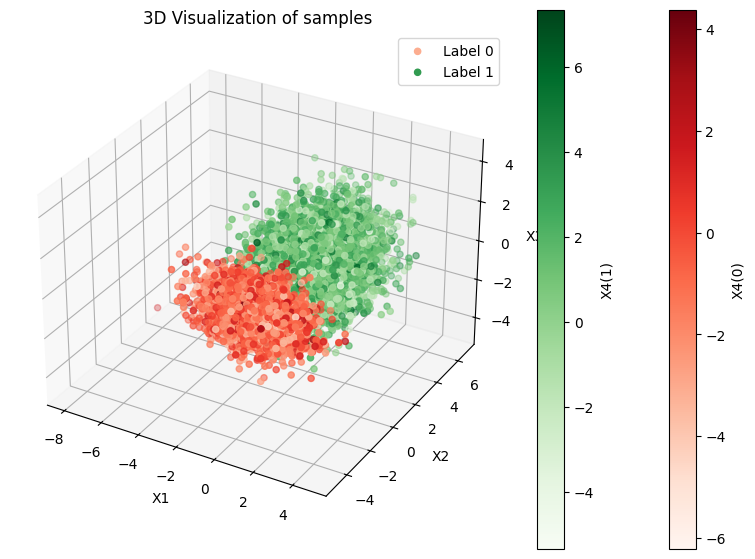

In [116]:
import matplotlib.pyplot as plt
# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot, color by ytrain values (classes or labels)
scatter0 = ax.scatter(samples[samples.labels == 0].iloc[:, 1], samples[samples.labels == 0].iloc[:, 2], samples[samples.labels == 0].iloc[:, 3], 
                     c=samples[samples.labels == 0].iloc[:, 4], cmap='Reds', marker='o', label = 'Label 0')
scatter1 = ax.scatter(samples[samples.labels == 1].iloc[:, 1], samples[samples.labels == 1].iloc[:, 2], samples[samples.labels == 1].iloc[:, 3], 
                     c=samples[samples.labels == 1].iloc[:, 4], cmap='Greens', marker='o', label = 'Label 1')


# Add labels and title
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title('3D Visualization of samples')

# Add color bar
cbar0 = plt.colorbar(scatter0)
cbar0.set_label('X4(0)')
cbar1 = plt.colorbar(scatter1)
cbar1.set_label('X4(1)')
plt.legend()
plt.show()


In [117]:
from scipy.stats import multivariate_normal
def likelihood_ratio(x, m0=m0, cov0=C0, m1=m1, cov1=C1):
    p_xL0 = multivariate_normal.pdf(x, mean=m0, cov = cov0)
    p_xL1 = multivariate_normal.pdf(x, mean=m1, cov = cov1)
    return p_xL1/p_xL0

def Gamma_Eval(g, samples = samples, m0=m0, m1=m1, cov0=C0, cov1=C1):
    tp, fp, tn, fn = 0, 0, 0, 0
    for i in range(len(samples)):
        x = np.array(samples.iloc[i, 1:])
        if (likelihood_ratio(x, m0=m0, cov0=cov0, m1=m1, cov1=cov1) > g):
            if samples.labels[i] == 1:
                tp += 1
            else:
                fp +=1
        else:
            if samples.labels[i] == 0:
                tn +=1
            else:
                fn +=1
    return np.array([g, fp/(tn+fp), tp/(tp+fn)])

# eval = pd.DataFrame(columns=['Gamma', 'False Alarm', 'Detection'])

# for g in np.linspace(0, 7, 200):
#     eval.loc[len(eval)] = Gamma_Eval(g)

# eval

In [118]:
eval = pd.read_csv('GammaValues.csv')
eval.head(7)

,Gamma,False Alarm,Detection
0,0.000000,1.000000,1.000000
1,0.035176,0.251966,0.995279
2,0.070352,0.179144,0.990407
3,0.105528,0.139237,0.986143
4,0.140704,0.115934,0.984468
5,0.175879,0.099621,0.982488
6,0.211055,0.090591,0.980356


In [119]:
# create a column including the error term for each gamma value
eval['error'] = eval['False Alarm']*p_L0 + (1 - eval['Detection'])*p_L1
# find the index of the row with minimum error
opt_index = eval.error.idxmin()
# what is the corresponding optimal gamma value for minimum error?
opt_gamma = eval['Gamma'][opt_index]

In [120]:
eval.iloc[opt_index]

Gamma          0.422111
False Alarm    0.051558
Detection      0.969240
error          0.038039
Name: 12, dtype: float64

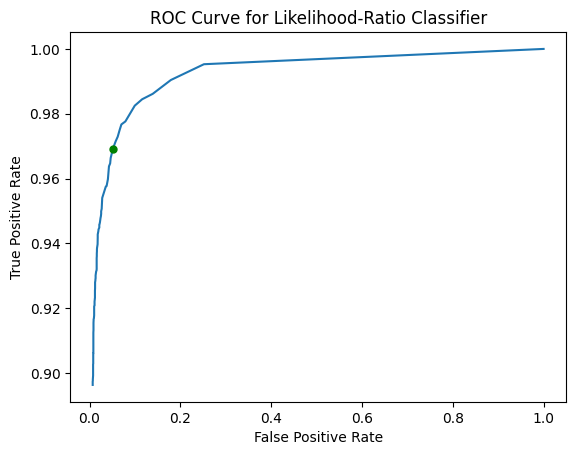

In [121]:
import matplotlib.pyplot as plt
# plot the probability of detection wrt false alarm
plt.plot(eval['False Alarm'], eval['Detection'])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
# specify the optimum value on the graph
plt.plot(eval['False Alarm'][opt_index], eval['Detection'][opt_index], marker = 'o', markersize=5, markeredgecolor="green", markerfacecolor="green")
plt.title("ROC Curve for Likelihood-Ratio Classifier")
plt.show()

c:\Users\tabat\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


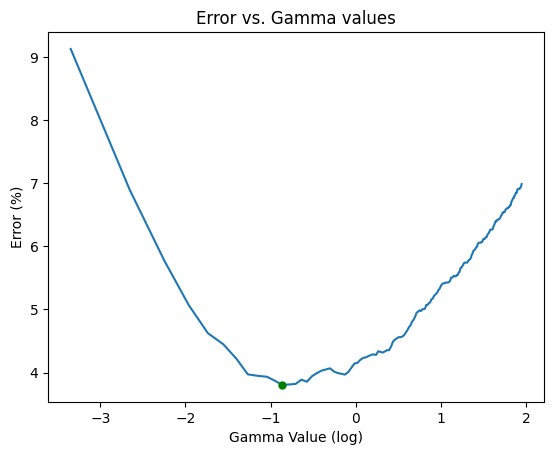

In [122]:
plt.plot(np.log(eval['Gamma']), eval['error']*100)
plt.xlabel("Gamma Value (log)")
plt.ylabel("Error (%)")
# specify the optimum value on the graph
plt.plot(np.log(eval['Gamma'][opt_index]), eval['error'][opt_index]*100, marker = 'o', markersize=5, markeredgecolor="green", markerfacecolor="green")
plt.title("Error vs. Gamma values")
plt.show()

In [123]:
from scipy.integrate import nquad
# time consuming! Do not run this! 
'''
def error_cal(x1, x2, x3, x4, m0=m0, m1=m1, cov0=C0, cov1=C1):
    x = np.array([x1, x2, x3, x4])
    p_xL0 = multivariate_normal.pdf(x, mean=m0, cov = cov0)
    p_xL1 = multivariate_normal.pdf(x, mean=m1, cov = cov1)
    return min(p_xL0*0.65,p_xL1*0.35)

opts = {'epsabs': 1.e-2}
err = nquad(error_cal, ranges = ([-5, 5], [-5, 5], [-5, 5], [-5, 5]), opts = opts)
err
'''


"\ndef error_cal(x1, x2, x3, x4, m0=m0, m1=m1, cov0=C0, cov1=C1):\n    x = np.array([x1, x2, x3, x4])\n    p_xL0 = multivariate_normal.pdf(x, mean=m0, cov = cov0)\n    p_xL1 = multivariate_normal.pdf(x, mean=m1, cov = cov1)\n    return min(p_xL0*0.65,p_xL1*0.35)\n\nopts = {'epsabs': 1.e-2}\nerr = nquad(error_cal, ranges = ([-5, 5], [-5, 5], [-5, 5], [-5, 5]), opts = opts)\nerr\n"

Part B

In [124]:
C0_d = np.diag(np.diag(C0))

C1_d = np.diag(np.diag(C1))
'''
evalB = pd.DataFrame(columns=['Gamma', 'False Alarm', 'Detection'])

for g in np.linspace(0, 7, 200):
    evalB.loc[len(evalB)] = Gamma_Eval(g, cov0=C0_d, cov1=C1_d)

evalB.to_csv('NaiveBayesGamma.csv', index=False)
'''

"\nevalB = pd.DataFrame(columns=['Gamma', 'False Alarm', 'Detection'])\n\nfor g in np.linspace(0, 7, 200):\n    evalB.loc[len(evalB)] = Gamma_Eval(g, cov0=C0_d, cov1=C1_d)\n\nevalB.to_csv('NaiveBayesGamma.csv', index=False)\n"

In [125]:
evalB = pd.read_csv('NaiveBayesGamma.csv')
evalB.head(10)

,Gamma,False Alarm,Detection
0,0.000000,1.000000,1.000000
1,0.035176,0.239732,0.993909
2,0.070352,0.172735,0.989493
3,0.105528,0.146228,0.985838
4,0.140704,0.122633,0.982488
5,0.175879,0.108943,0.979899
6,0.211055,0.100204,0.977006
7,0.246231,0.092630,0.975483
8,0.281407,0.084474,0.973352
9,0.316583,0.075444,0.970915


In [126]:
# create a column including the error term for each gamma value
evalB['error'] = evalB['False Alarm']*p_L0 + (1 - evalB['Detection'])*p_L1
# find the index of the row with minimum error
opt_index = evalB.error.idxmin()
# what is the corresponding optimal gamma value for minimum error?
opt_gamma = evalB['Gamma'][opt_index]
evalB.iloc[opt_index]

Gamma          0.316583
False Alarm    0.075444
Detection      0.970915
error          0.045311
Name: 9, dtype: float64

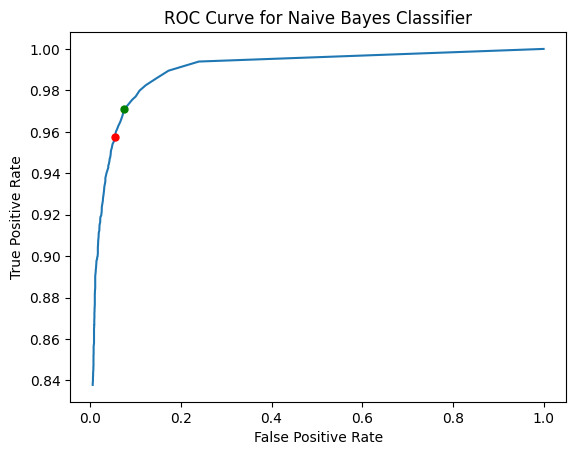

In [127]:
import matplotlib.pyplot as plt
# plot the probability of detection wrt false alarm
plt.plot(evalB['False Alarm'], evalB['Detection'])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
# specify the optimum value on the graph
plt.plot(evalB['False Alarm'][opt_index], evalB['Detection'][opt_index], marker = 'o', markersize=5, markeredgecolor="green", markerfacecolor="green")
plt.plot(evalB['False Alarm'][15], evalB['Detection'][15], marker = 'o', markersize=5, markeredgecolor="red", markerfacecolor="red")
plt.title("ROC Curve for Naive Bayes Classifier")
plt.show()

c:\Users\tabat\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


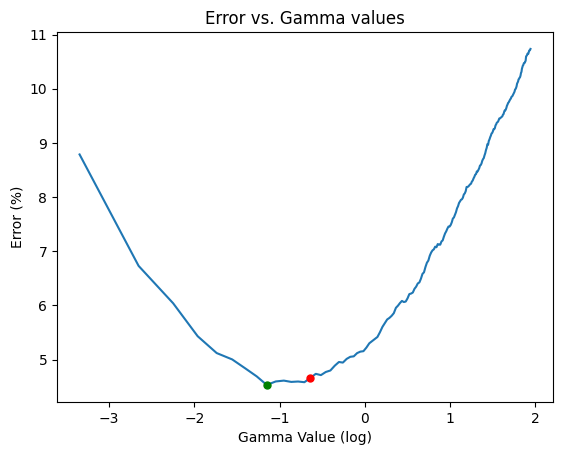

In [128]:
plt.plot(np.log(evalB['Gamma']), evalB['error']*100)
plt.xlabel("Gamma Value (log)")
plt.ylabel("Error (%)")
# specify the optimum value on the graph
plt.plot(np.log(evalB['Gamma'][opt_index]), evalB['error'][opt_index]*100, marker = 'o', markersize=5, markeredgecolor="green", markerfacecolor="green")
plt.plot(np.log(evalB['Gamma'][15]), evalB['error'][15]*100, marker = 'o', markersize=5, markeredgecolor="red", markerfacecolor="red")
plt.title("Error vs. Gamma values")
plt.show()

In [129]:
# This cell is computationally expensive. Do not run it!
'''
opts = {'epsabs': 1.e-2}
def error_calNB(x1, x2, x3, x4, m0=m0, m1=m1, cov0=C0_d, cov1=C1_d):
    x = np.array([x1, x2, x3, x4])
    p_xL0 = multivariate_normal.pdf(x, mean=m0, cov = cov0)
    p_xL1 = multivariate_normal.pdf(x, mean=m1, cov = cov1)
    return min(p_xL0*0.65,p_xL1*0.35)
err = nquad(error_calNB, ranges = ([-5, 5], [-5, 5], [-5, 5], [-5, 5]), opts = opts)
err
'''

"\nopts = {'epsabs': 1.e-2}\ndef error_calNB(x1, x2, x3, x4, m0=m0, m1=m1, cov0=C0_d, cov1=C1_d):\n    x = np.array([x1, x2, x3, x4])\n    p_xL0 = multivariate_normal.pdf(x, mean=m0, cov = cov0)\n    p_xL1 = multivariate_normal.pdf(x, mean=m1, cov = cov1)\n    return min(p_xL0*0.65,p_xL1*0.35)\nerr = nquad(error_calNB, ranges = ([-5, 5], [-5, 5], [-5, 5], [-5, 5]), opts = opts)\nerr\n"

Part C

In [130]:
from numpy.linalg import inv
# estimate the mean and covariance matrix of each class
mean0 = (samples[samples['labels']==0].iloc[:, 1:]).mean()
mean1 = (samples[samples['labels']==1].iloc[:, 1:]).mean()
cov0 = (samples[samples['labels']==0].iloc[:, 1:]).cov()
cov1 = (samples[samples['labels']==1].iloc[:, 1:]).cov()

# estimate the withon class scaatter
s_w = cov0+cov1
# estimate the between class scatter
s_b = np.outer(np.array(mean1-mean0),np.array(mean1-mean0).T)
inv(s_w) @ s_b

array([[1.36847131, 1.40607248, 1.36114149, 1.38658972],
       [1.53675218, 1.57897716, 1.52852101, 1.5570986 ],
       [2.01029889, 2.06553541, 1.9995313 , 2.03691502],
       [0.77390778, 0.79517227, 0.76976257, 0.78415423]])

In [131]:
from numpy.linalg import inv
j_w = np.dot(inv(s_w), s_b)
j_w
eigval, eigvec = np.linalg.eig(j_w)
sorted = np.argsort(eigval)[::-1]
w_lda = eigvec[:, sorted[0]]
w_lda

array([-0.45936974, -0.51585842, -0.67481903, -0.25978609])

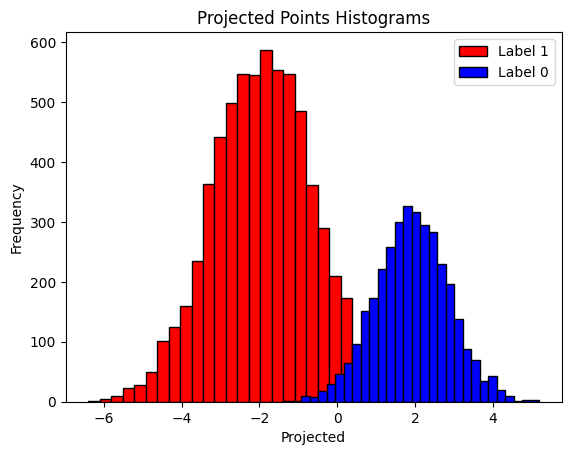

In [132]:
# project data points
projected = np.dot(np.array(samples.iloc[:, 1:]), w_lda)
# separate the projected points based on labels
class0 = [projected[i] for i in samples[samples.labels == 0].index]
class1 = [projected[i] for i in samples[samples.labels == 1].index]

plt.xlabel("Projected")
plt.ylabel("Frequency")

plt.hist(class1, bins=30, color='red', edgecolor='black', label= 'Label 1')
plt.hist(class0, bins=30, color='blue', edgecolor='black', label='Label 0')

plt.title("Projected Points Histograms")
plt.legend()
plt.show()

In [133]:
tau_eval = pd.DataFrame(columns = ['Tau', 'False Alarm', 'Detection'])
for tau in np.linspace(0, 7, 200):
    trace = projected <= tau
    tpr = np.sum((trace == True) & (samples.labels == 1))/np.sum(samples.labels == 1)
    fpr = np.sum((trace == True) & (samples.labels == 0))/np.sum(samples.labels == 0)
    tau_eval.loc[len(tau_eval)] = [tau, fpr, tpr]

tau_eval

,Tau,False Alarm,Detection
0,0.000000,0.022138,0.929191
1,0.035176,0.024177,0.933760
2,0.070352,0.026216,0.936348
3,0.105528,0.027381,0.939242
4,0.140704,0.029712,0.943201
...,...,...,...
195,6.859296,1.000000,1.000000
196,6.894472,1.000000,1.000000
197,6.929648,1.000000,1.000000
198,6.964824,1.000000,1.000000


In [134]:
# create a column including the error term for each gamma value
tau_eval['error'] = tau_eval['False Alarm']*p_L0 + (1 - tau_eval['Detection'])*p_L1
# find the index of the row with minimum error
opt_index = tau_eval.error.idxmin()
# what is the corresponding optimal tau value for minimum error?
opt_tau = tau_eval['Tau'][opt_index]
tau_eval.iloc[opt_index]

Tau            0.386935
False Alarm    0.051850
Detection      0.964367
error          0.041309
Name: 11, dtype: float64

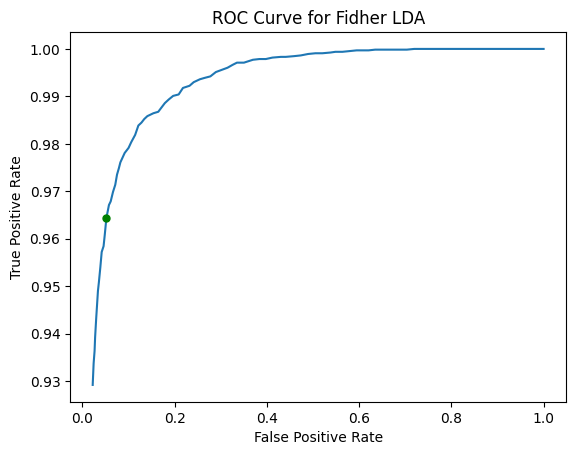

In [135]:
import matplotlib.pyplot as plt
# plot the probability of detection wrt false alarm
plt.plot(tau_eval['False Alarm'], tau_eval['Detection'])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
# specify the optimum value on the graph
plt.plot(tau_eval['False Alarm'][opt_index], tau_eval['Detection'][opt_index], marker = 'o', markersize=5, markeredgecolor="green", markerfacecolor="green")
# plt.plot(tau_eval['False Alarm'][15], tau_eval['Detection'][15], marker = 'o', markersize=5, markeredgecolor="red", markerfacecolor="red")
plt.title("ROC Curve for Fidher LDA")
plt.show()

c:\Users\tabat\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


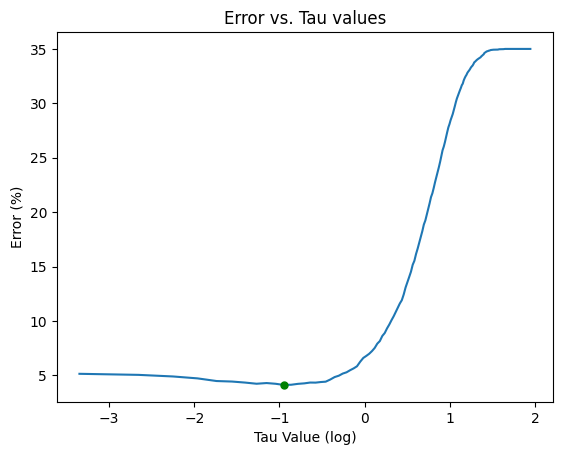

In [136]:
plt.plot(np.log(tau_eval['Tau']), tau_eval['error']*100)
plt.xlabel("Tau Value (log)")
plt.ylabel("Error (%)")
# specify the optimum value on the graph
plt.plot(np.log(tau_eval['Tau'][opt_index]), tau_eval['error'][opt_index]*100, marker = 'o', markersize=5, markeredgecolor="green", markerfacecolor="green")
# plt.plot(np.log(tau_eval['Tau'][15]), tau_eval['error'][15]*100, marker = 'o', markersize=5, markeredgecolor="red", markerfacecolor="red")
plt.title("Error vs. Tau values")
plt.show()

# Question 3
Wine Quality

In [185]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes)
X = wine_quality.data.features 
y = wine_quality.data.targets 

# metadata
print(wine_quality.metadata)

# variable information 
print(wine_quality.variables)

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

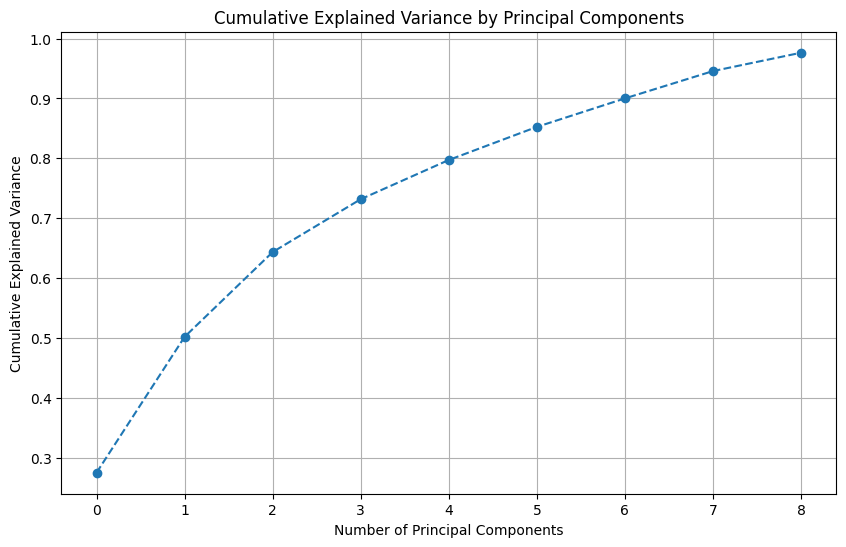

Number of components explaining 95% of variance: 9


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,Quality
0,-3.205996,0.416523,-2.722237,-0.796778,-0.202877,-0.227363,-0.325554,-0.567278,-0.071229,5
1,-3.039051,1.107462,-2.046952,-0.770225,1.322655,1.655121,0.059559,-0.514603,0.429129,5
2,-3.071893,0.878964,-1.742580,-0.802257,0.762112,0.848374,0.167670,-0.420952,0.271032,5
3,-1.571262,2.112545,2.592917,-0.292785,-0.604701,-0.713308,-0.851217,-0.929669,-0.549410,6
4,-3.205996,0.416523,-2.722237,-0.796778,-0.202877,-0.227363,-0.325554,-0.567278,-0.071229,5
...,...,...,...,...,...,...,...,...,...,...
6492,-0.062824,-1.934205,0.223912,0.189443,-0.000146,-0.629250,0.367168,-0.048457,-0.070114,6
6493,1.866989,0.524431,-0.431798,0.183000,0.518028,0.188672,-0.372130,-0.236534,0.122212,5
6494,0.571133,-0.722662,0.091469,-0.939670,1.262008,-0.553014,1.047896,-1.068127,0.133957,6
6495,0.090052,-3.545780,0.141195,-0.055725,-0.208807,-0.148921,-0.380177,0.638527,0.255940,7


In [149]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize the data (for Gassian model)
X = StandardScaler().fit_transform(X)

# Apply PCA to retain 95% of variance
pca = PCA(n_components=0.95)
WineQual_pca = pca.fit_transform(X)

# Explained variance ratio to understand how many components are selected
explained_variance = pca.explained_variance_ratio_

# Plot the cumulative explained variance to decide the number of components
plt.figure(figsize=(10,6))
plt.plot(np.cumsum(explained_variance), marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Get the number of components that explain 95% of the variance
n_components = pca.n_components_
print(f"Number of components explaining 95% of variance: {n_components}")

WineQual_3d = pd.DataFrame(WineQual_pca, columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9'])
WineQual_3d['Quality'] = y
WineQual_3d

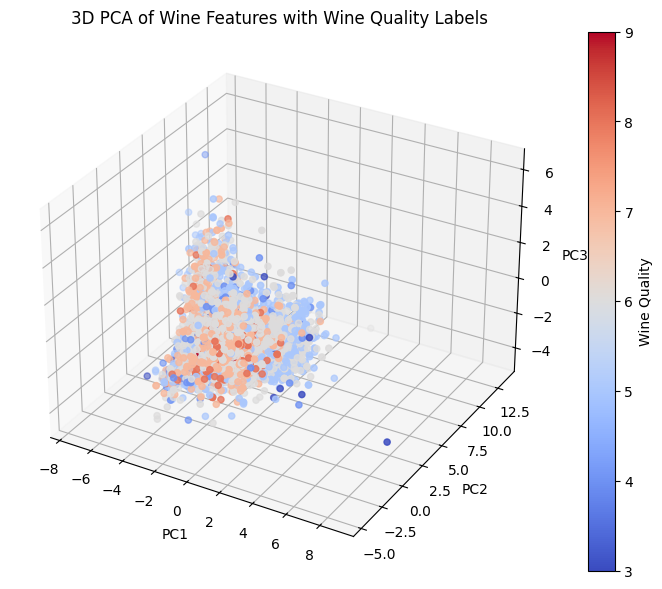

In [150]:
# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot, color by ytrain values (classes or labels)
scatter = ax.scatter(WineQual_3d.iloc[:, 0], WineQual_3d.iloc[:, 1], WineQual_3d.iloc[:, 2], 
                     c=y, cmap='coolwarm', marker='o')

# Add labels and title
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA of Wine Features with Wine Quality Labels')

# Add color bar
cbar = plt.colorbar(scatter)
cbar.set_label('Wine Quality')

plt.show()


In [151]:
# calculate the class priors with the estimated Gaussian class conditional pdf
wine = pd.DataFrame()
wine['Wine Quality'] , counts = np.unique(y, return_counts=True)
wine['Prior'] = counts/len(y)
wine

,Wine Quality,Prior
0,3,0.004618
1,4,0.033246
2,5,0.329075
3,6,0.436509
4,7,0.166077
5,8,0.029706
6,9,0.000770


In [152]:
# estimate the mean and covariance matrices for each class
means = pd.DataFrame(columns=['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11'])
covar = []
for c in wine['Wine Quality']:
    means.loc[len(means)] = np.array(np.mean(X[y['quality']==c], axis=0))
    covar.append(np.cov(X[y['quality']==c], rowvar=False))

means.insert(loc=0, column='Quality', value=wine['Wine Quality'])
display(means)
means = np.array(means.iloc[:, 1:]) # drop the quality column for further calculations using mean values
print('For instance, the covariance matrix for wine quality of 6 is:')
display(pd.DataFrame(covar[3]))

,Quality,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11
0,3,0.492177,1.077208,-0.258992,-0.063739,0.599456,0.489708,0.111271,0.349303,0.243607,-0.167580,-0.232095
1,4,0.056761,0.718590,-0.318763,-0.271056,0.114804,-0.557174,-0.217839,0.045359,0.081602,-0.172185,-0.261364
2,5,0.086007,0.303408,-0.075090,0.075856,0.246416,-0.016224,0.090141,0.384317,-0.039259,-0.032697,-0.548387
3,6,-0.029352,-0.156740,0.034061,0.022390,-0.053570,0.036044,-0.005906,-0.046122,-0.004822,0.008610,0.080287
4,7,-0.066607,-0.308984,0.111010,-0.149564,-0.307197,-0.005813,-0.128207,-0.523846,0.059533,0.105896,0.749782
5,8,-0.293191,-0.295557,0.095699,-0.012682,-0.425610,0.225848,0.031381,-0.728082,0.029306,-0.126223,0.995251
6,9,0.157901,-0.253098,0.463618,-0.278140,-0.817389,0.161972,0.004519,-1.079438,0.556674,-0.438647,1.415538


For instance, the covariance matrix for wine quality of 6 is:


,0,1,2,3,4,5,6,7,8,9,10
0,0.992081,0.197683,0.308115,-0.126604,0.276279,-0.262804,-0.322145,0.437580,-0.226821,0.324128,-0.063438
1,0.197683,0.798214,-0.314426,-0.149409,0.297179,-0.314107,-0.390667,0.237037,0.238691,0.255744,0.047663
2,0.308115,-0.314426,0.961748,0.093166,0.024690,0.095403,0.173364,0.072750,-0.290325,0.017644,-0.015004
3,-0.126604,-0.149409,0.093166,1.055743,-0.139176,0.396732,0.475391,0.613174,-0.246738,-0.205698,-0.376690
4,0.276279,0.297179,0.024690,-0.139176,0.775211,-0.183293,-0.292513,0.302787,0.078381,0.312958,-0.177112
5,-0.262804,-0.314107,0.095403,0.396732,-0.183293,0.899812,0.669812,0.042755,-0.152325,-0.233930,-0.213208
6,-0.322145,-0.390667,0.173364,0.475391,-0.292513,0.669812,0.962733,0.017772,-0.218513,-0.297303,-0.251012
7,0.437580,0.237037,0.072750,0.613174,0.302787,0.042755,0.017772,1.024552,0.056556,0.282659,-0.624319
8,-0.226821,0.238691,-0.290325,-0.246738,0.078381,-0.152325,-0.218513,0.056556,1.002808,0.214746,0.081307
9,0.324128,0.255744,0.017644,-0.205698,0.312958,-0.233930,-0.297303,0.282659,0.214746,0.972587,-0.032477


In [153]:
# define a function to measure regularization parameter of a given covariance matrix
def reg_parm(alpha=0.05, cov=None):
    return alpha*np.trace(cov)/np.linalg.matrix_rank(cov) # the recommended formula to measure the regularization parameter
# record regularization parameters in a dataframe
RegParm = pd.DataFrame(columns=['Quality', 'RegularParm'])
RegParm['Quality'] = wine['Wine Quality']
# iterate over covariance matrices of all classes
for i in range(len(covar)):
    RegParm.loc[i, 'RegularParm']= reg_parm(cov=covar[i]) # save the parameters in  dataframe

RegParm

,Quality,RegularParm
0,3,0.142196
1,4,0.059883
2,5,0.050564
3,6,0.046989
4,7,0.040553
5,8,0.038845
6,9,0.060482


In [154]:
# define a function to regularize the covariance matrix is it is ill-conditioned
def regularized_covariance(cov_mat, alpha=0.05): # alpha is a small arbitrary value chosen between 0 and 1
    if np.linalg.cond(cov_mat)>1.e5: # the threshold to figure out whether the covariance matrix is ill-conditioned
        return cov_mat+reg_parm(alpha=alpha, cov=cov_mat)*np.eye(cov_mat.shape[0]) # uses the recommended formula to regularize the covariance matrix
    else:
        return cov_mat
# record the regularized covariance matrices in an array
reg_covar = []
for i in range(len(covar)):
    reg_covar.append(regularized_covariance(cov_mat=covar[i]))

print('For instance, regularized covariance matrix for wine quality of 6 is:')
pd.DataFrame(reg_covar[3])

For instance, regularized covariance matrix for wine quality of 6 is:


,0,1,2,3,4,5,6,7,8,9,10
0,0.992081,0.197683,0.308115,-0.126604,0.276279,-0.262804,-0.322145,0.437580,-0.226821,0.324128,-0.063438
1,0.197683,0.798214,-0.314426,-0.149409,0.297179,-0.314107,-0.390667,0.237037,0.238691,0.255744,0.047663
2,0.308115,-0.314426,0.961748,0.093166,0.024690,0.095403,0.173364,0.072750,-0.290325,0.017644,-0.015004
3,-0.126604,-0.149409,0.093166,1.055743,-0.139176,0.396732,0.475391,0.613174,-0.246738,-0.205698,-0.376690
4,0.276279,0.297179,0.024690,-0.139176,0.775211,-0.183293,-0.292513,0.302787,0.078381,0.312958,-0.177112
5,-0.262804,-0.314107,0.095403,0.396732,-0.183293,0.899812,0.669812,0.042755,-0.152325,-0.233930,-0.213208
6,-0.322145,-0.390667,0.173364,0.475391,-0.292513,0.669812,0.962733,0.017772,-0.218513,-0.297303,-0.251012
7,0.437580,0.237037,0.072750,0.613174,0.302787,0.042755,0.017772,1.024552,0.056556,0.282659,-0.624319
8,-0.226821,0.238691,-0.290325,-0.246738,0.078381,-0.152325,-0.218513,0.056556,1.002808,0.214746,0.081307
9,0.324128,0.255744,0.017644,-0.205698,0.312958,-0.233930,-0.297303,0.282659,0.214746,0.972587,-0.032477


In [159]:
# define a function for the minimum probability of error classifier
def MinErrClassify(x, means, covariances, priors):
    posteriors = []
    for i in range(len(means)):
        likelihood = multivariate_normal.pdf(x, mean=means[i], cov=covariances[i]) # probability of x belonging to i-th class
        posterior = likelihood * priors[i]
        posteriors.append(posterior)
    return np.argmax(posteriors)+3 # return the class with highest posterior (the +3 refers to the difference between indices and class labels)

# classify all samples in the training set
predictions = np.array([MinErrClassify(x, means, reg_covar, wine['Prior']) for x in np.array(X)])

Error Probability: 49.87%


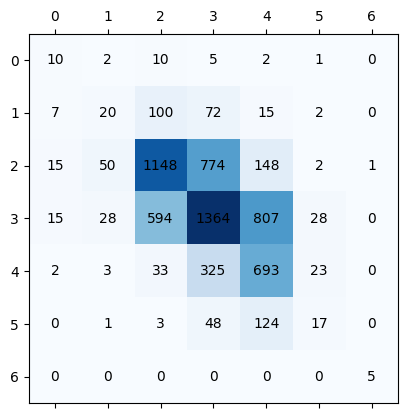

In [162]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Confusion matrix
conf = confusion_matrix(y, predictions)

# Error probability
error = 1 - accuracy_score(y, predictions)

print("Error Probability: {:.2f}%".format(error * 100))
fig, ax = plt.subplots()
ax.matshow(conf, cmap=plt.cm.Blues)

for i in range(len(means)):
    for j in range(len(means)):
        c = conf[j,i]
        ax.text(i, j, str(c), va='center', ha='center')

Human Activity (train)

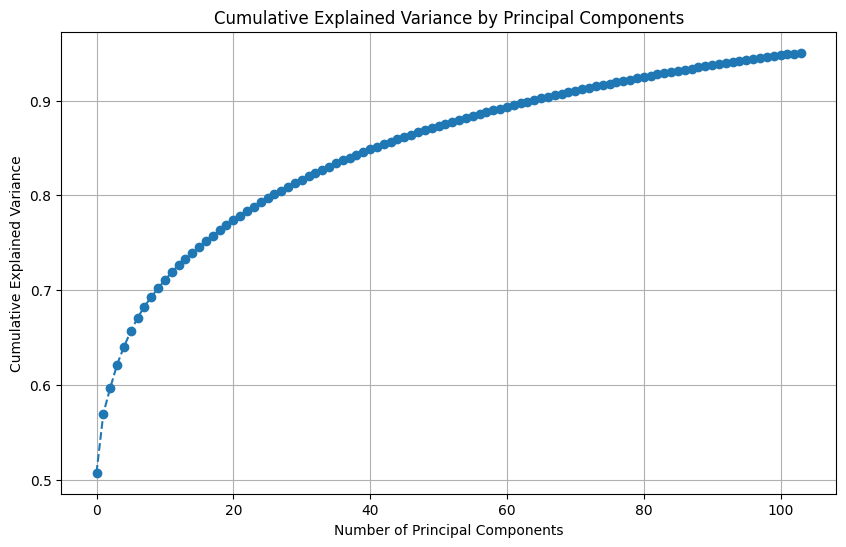

Number of components explaining 95% of variance: 104


,PC1,PC2,PC3,Activity
0,-16.380980,1.995083,3.415690,5
1,-15.582173,1.182594,-0.321207,5
2,-15.423989,2.243166,-1.237784,5
3,-15.647807,3.762882,-1.275283,5
4,-15.842320,4.438897,-1.808232,5
...,...,...,...,...
10294,10.166057,-6.504223,-1.055480,2
10295,12.131154,-4.882447,-0.652943,2
10296,11.846853,-3.433565,2.188019,2
10297,8.206686,-4.386489,1.318720,2


In [177]:
xtrain = pd.read_csv('xtrain.csv').iloc[:, 1:]
ytrain = pd.read_csv('ytrain.csv')
xtrain.dropna()
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize the data (for Gassian model)
xtrain = StandardScaler().fit_transform(xtrain)

# Apply PCA to retain 95% of variance
pca = PCA(n_components=0.95) 
Human_pca = pca.fit_transform(xtrain)

# Explained variance ratio to understand how many components are selected
explained_variance = pca.explained_variance_ratio_

# Plot the cumulative explained variance to decide the number of components
plt.figure(figsize=(10,6))
plt.plot(np.cumsum(explained_variance), marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Get the number of components that explain 95% of the variance
n_components = pca.n_components_
print(f"Number of components explaining 95% of variance: {n_components}")

Human_3d = pd.DataFrame(Human_pca[:, :3], columns = ['PC1', 'PC2', 'PC3'])
Human_3d['Activity'] = np.array(ytrain).flatten()
Human_3d

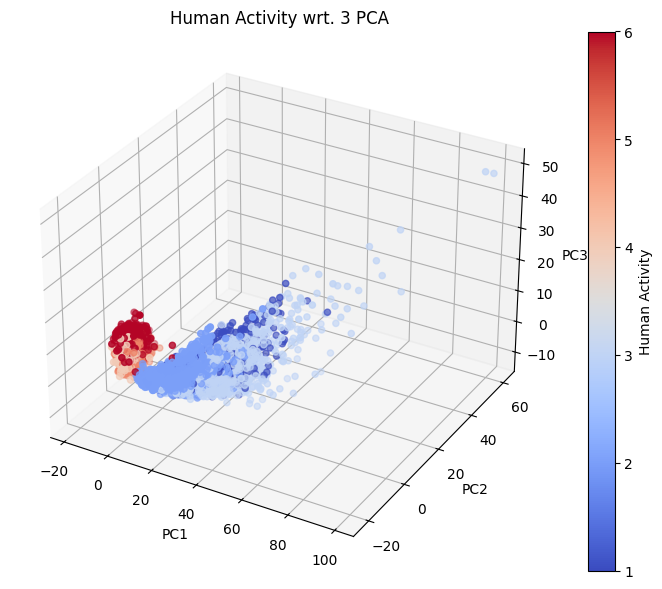

In [178]:
# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot, color by ytrain values (classes or labels)
scatter = ax.scatter(Human_3d.iloc[:, 0], Human_3d.iloc[:, 1], Human_3d.iloc[:, 2], 
                     c=ytrain, cmap='coolwarm', marker='o')

# Add labels and title
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Human Activity wrt. 3 PCA')

# Add color bar
cbar = plt.colorbar(scatter)
cbar.set_label('Human Activity')

plt.show()


In [179]:
human = pd.DataFrame()
human['Human Activity'] , counts = np.unique(ytrain, return_counts=True)
human['Prior'] = counts/len(ytrain)
human

,Human Activity,Prior
0,1,0.167201
1,2,0.149917
2,3,0.136518
3,4,0.172541
4,5,0.185067
5,6,0.188756


In [180]:
ytrain = np.array(ytrain).flatten()
means = pd.DataFrame(columns=['PC1', 'PC2', 'PC3', 'Activity'])
covar = []
for c in human['Human Activity']:
    means.loc[len(means)] = np.array(np.mean(Human_3d[ytrain==c], axis=0))
    covar.append(np.cov(Human_3d.iloc[:, :3][ytrain==c], rowvar=False))

display(means)
means = np.array(means.iloc[:, :-1])
print('For instance, the covariance matrix for human activity of 4 is:')
display(pd.DataFrame(covar[3], columns = ['PC1', 'PC2', 'PC3'], index=['PC1', 'PC2', 'PC3']))

,PC1,PC2,PC3,Activity
0,15.817736,1.236847,-2.263117,1.0
1,12.654609,-6.720999,0.359631,2.0
2,23.324373,2.125937,-0.145166,3.0
3,-14.230023,0.830008,0.110431,4.0
4,-13.626720,-0.191670,-0.818645,5.0
5,-14.563605,2.134107,2.525731,6.0


For instance, the covariance matrix for human activity of 4 is:


,PC1,PC2,PC3
PC1,6.389093,-11.343466,2.723215
PC2,-11.343466,28.234685,-9.370904
PC3,2.723215,-9.370904,7.012219


In [181]:
def reg_parm(alpha=0.01, cov=None):
    return alpha*np.trace(cov)/np.linalg.matrix_rank(cov) # the recommended formula to measure the regularization parameter
RegParm = pd.DataFrame(columns=['Activity', 'RegularParm'])
RegParm['Activity'] = human['Human Activity']
for i in range(len(covar)):
    RegParm.loc[i, 'RegularParm']= reg_parm(cov=covar[i]) # save the parameters in  dataframe

RegParm

,Activity,RegularParm
0,1,0.323012
1,2,0.226806
2,3,0.652252
3,4,0.138787
4,5,0.097597
5,6,0.155198


In [182]:
def regularized_covariance(cov_mat, alpha=0.01): # alpha is a small arbitrary value chosen between 0 and 1
    if np.linalg.cond(cov_mat)>1.e5: # the threshold to figure out whether the covariance matrix is ill-conditioned
        return cov_mat+reg_parm(alpha=alpha, cov=cov_mat)*np.eye(cov_mat.shape[0]) # uses the recommended formula to regularize the covariance matrix
    else:
        return cov_mat

reg_covar = []
for i in range(len(covar)):
    reg_covar.append(regularized_covariance(cov_mat=covar[i]))

print('For instance, regularized covariance matrix for human activity of 4 is:')
pd.DataFrame(reg_covar[3], columns = ['PC1', 'PC2', 'PC3'], index=['PC1', 'PC2', 'PC3'])

For instance, regularized covariance matrix for human activity of 4 is:


,PC1,PC2,PC3
PC1,6.389093,-11.343466,2.723215
PC2,-11.343466,28.234685,-9.370904
PC3,2.723215,-9.370904,7.012219


In [183]:
def MinErrClassify(x, means, covariances, priors):
    posteriors = []
    for i in range(len(means)):
        likelihood = multivariate_normal.pdf(x, mean=means[i], cov=covariances[i])
        posterior = likelihood * priors[i]
        posteriors.append(posterior)
    return np.argmax(posteriors)+1

# Classify all samples in the training set
predictions = np.array([MinErrClassify(x, means, reg_covar, human['Prior']) for x in np.array(Human_3d.iloc[:, :3])])

Error Probability: 31.30%


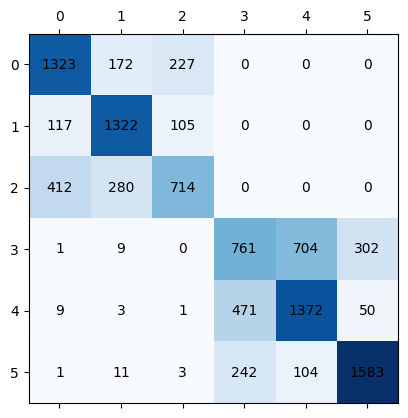

In [184]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Confusion matrix
conf = confusion_matrix(ytrain, predictions)

# Error probability
error = 1 - accuracy_score(ytrain, predictions)

print("Error Probability: {:.2f}%".format(error * 100))
fig, ax = plt.subplots()
ax.matshow(conf, cmap=plt.cm.Blues)

for i in range(len(means)):
    for j in range(len(means)):
        c = conf[j,i]
        ax.text(i, j, str(c), va='center', ha='center')

In [94]:
np.linalg.cond(covar[1][:3, :3])

14.994227599582343

In [147]:
means

array([[ 0.49217738,  1.07720753, -0.25899164, -0.06373922,  0.59945558,
         0.48970762,  0.11127099,  0.34930344,  0.24360667, -0.16757983,
        -0.23209475],
       [ 0.05676147,  0.71858966, -0.31876305, -0.27105592,  0.11480416,
        -0.55717413, -0.21783878,  0.04535857,  0.08160185, -0.17218475,
        -0.26136427],
       [ 0.08600691,  0.30340768, -0.07508977,  0.0758561 ,  0.24641616,
        -0.01622422,  0.0901407 ,  0.38431741, -0.03925916, -0.03269677,
        -0.54838748],
       [-0.02935229, -0.15674018,  0.03406103,  0.02238975, -0.05356978,
         0.03604353, -0.00590586, -0.04612157, -0.0048215 ,  0.00860978,
         0.08028715],
       [-0.06660711, -0.30898439,  0.11100973, -0.14956357, -0.30719695,
        -0.005813  , -0.12820744, -0.52384566,  0.05953322,  0.10589608,
         0.74978179],
       [-0.29319135, -0.29555651,  0.09569859, -0.01268199, -0.42561017,
         0.22584808,  0.03138073, -0.72808157,  0.02930551, -0.12622268,
         0.995